# A two-line approximation separates the fitted boundary from measured saturation.

Seol Handong

The additive cost in [the problem formulation](../../../../preliminary_research/idea.md) is

$$L_{\mathrm{table}}(M)=\sum_{C\in\mathcal C(M)}T[|C|].$$

An affine approximation simplifies this sum. A two-line approximation allows a change in slope, but introduces a boundary whose meaning must be specified. We distinguish a measured efficiency minimum, a throughput crossing and a fitted breakpoint.

The figures use the previously recorded native-reader data: `block_estimates.csv` is an unchanged copy of `block_estimates1.csv`. No new SSD measurements were taken for this report. The separate Python-reader data in `block_estimates2.csv` are not combined with this reference.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from IPython.display import Markdown, display

CSV_PATH = Path("block_estimates.csv")
SUBMODULE = Path("../../../upstream/vlm-flash")
RERUN_MEASUREMENTS = False
SIZES_KIB = np.r_[np.arange(1, 257), np.arange(260, 769, 4)]
BLOCKS, ITERS, WARMUP, THREADS, BLOB_MIB = 7, 10, 3, 6, 128

## The native count sweep defines an amortized chunk cost.

Let $z>0$ be a logical chunk length in KiB. For count $n_j$, let $u_{b,j}(z)$ be the median native batch time in microseconds in block $b$. Then

$$D_j(z)=\frac{n_jz}{1024}\ \mathrm{MiB},\qquad
\beta_{b,j}(z)=\frac{10^6D_j(z)}{u_{b,j}(z)}\ \mathrm{MiB/s}.$$

The submodule's `saturation_throughput` averages the count-sweep tail selected by its three-point-mean slope rule; if no crossing exists, it uses its last-20% fallback. With fewer than three count points, it uses the last point. Writing its result as $\widehat\beta_b(z)$ gives

$$\boxed{\widehat T_b(z)=\frac{1000z}{1024\widehat\beta_b(z)}\quad\mathrm{ms/chunk}.}$$

This is a throughput-derived cost, not the service time of an isolated read. Logical bytes exclude alignment padding.

Acquisition calls the checked-out [profiler](../../../upstream/vlm-flash/scripts/profile_flash.py) and [native reader](../../../upstream/vlm-flash/src/vlmflash/csrc/native.cc), recorded here at submodule revision `9023679`. Blob preparation, count schedule, 32 KiB gaps, warmups, native timing, alignment, destination buffers and thread scheduling remain upstream operations. Seven randomized blocks on the 384-size grid extend the original single sweep; they do not replace its reader or estimator. A wrapper only rejects buffered fallback, outside the native timed interval.

The acquisition definition is folded below. With `RERUN_MEASUREMENTS = False`, evaluation reads the saved CSV; a missing file does not start a measurement. Paths are relative to this notebook. Fresh acquisition requires the initialized submodule and its native build dependencies, with the CSV directory on the target SSD.

In [2]:
def measure(directory):
    import sys
    from contextlib import redirect_stdout
    from io import StringIO
    from tempfile import TemporaryDirectory

    sys.path[:0] = [str((SUBMODULE / p).resolve()) for p in ("scripts", "src")]
    import profile_flash as profiler

    native_reader = profiler.native()
    if native_reader is None:
        raise RuntimeError(profiler.unavailable_reason())

    class DirectOnly:
        def read_rows(self, *args, **kwargs):
            result = native_reader.read_rows(*args, **kwargs)
            if not result[3]:
                raise RuntimeError("O_DIRECT unavailable; no latency profile was saved.")
            return result

    reader = DirectOnly()
    num_rows = BLOB_MIB * 1024 // profiler.ROW_KB
    rng, records = np.random.default_rng(0), []
    with profiler.exclusive("01_chunk_latency"), TemporaryDirectory(dir=directory) as work:
        blob = str(Path(work) / "profile_blob.dat")
        with redirect_stdout(StringIO()):
            profiler.prepare_blob(blob, num_rows)
            for block in range(BLOCKS):
                for order, size in enumerate(rng.permutation(SIZES_KIB)):
                    size = int(size)
                    runs = profiler.measure(reader, blob, num_rows, [size],
                                            ITERS, WARMUP, THREADS)[size]
                    rate = profiler.saturation_throughput(runs, size)
                    records.append(dict(block=block, order=order, size_kib=size,
                        latency_ms=1000 * size / (1024 * rate),
                        throughput_mib_s=rate, count_points=len(runs),
                        max_count=runs[-1][0]))
    return pd.DataFrame(records)

In [3]:
if RERUN_MEASUREMENTS:
    data = measure(CSV_PATH.parent)
    data.to_csv(CSV_PATH, index=False)
else:
    data = pd.read_csv(CSV_PATH)

Define $T(z)$ as the median over the seven blocks. The first four define $T_{\mathrm{train}}$; the remaining three define $T_{\mathrm{test}}$. Coefficients and free boundaries are fitted to $T_{\mathrm{train}}$ only.

Each size occurs once per block, with positive finite costs satisfying the throughput identity above. The folded check enforces these conditions before fitting. It does not prescribe a numerical breakpoint.

In [ ]:
columns = {
    "block", "order", "size_kib", "latency_ms", "throughput_mib_s",
    "count_points", "max_count",
}
assert set(data) == columns, "The profile must use the seven-column schema."
assert len(data) == BLOCKS * len(SIZES_KIB), "The block grid is incomplete."
assert set(data.block) == set(range(BLOCKS))
assert set(data.size_kib) == set(SIZES_KIB)
assert not data.duplicated(["block", "size_kib"]).any()
assert not data.duplicated(["block", "order"]).any()
assert data.order.between(0, len(SIZES_KIB) - 1).all()
indices = data[["block", "order", "size_kib", "count_points", "max_count"]].to_numpy(float)
assert np.isfinite(indices).all() and (indices == np.floor(indices)).all()
values = data[["latency_ms", "throughput_mib_s", "count_points", "max_count"]].to_numpy(float)
assert np.isfinite(values).all() and (values > 0).all()
np.testing.assert_allclose(
    data.latency_ms, 1000 * data.size_kib / (1024 * data.throughput_mib_s),
    rtol=1e-9, atol=1e-12,
)

In [4]:
wide = data.pivot(index="size_kib", columns="block", values="latency_ms")
wide = wide.sort_index().sort_index(axis=1)
z, samples = wide.index.to_numpy(float), wide.to_numpy(float)
T = np.median(samples, axis=1)
T_train = np.median(samples[:, :4], axis=1)
T_test = np.median(samples[:, 4:], axis=1)

## The efficiency minimum and the first throughput crossing need not agree.

Define

$$\rho(z)=\frac{T(z)}z,\qquad z_\rho\in\arg\min_{z\in\mathcal G}\rho(z).$$

Since $\beta(z)=1000/(1024\rho(z))$, minimizing cost per KiB is equivalent to maximizing throughput on the same curve. The submodule's separate size-trimming rule uses a three-point **median**, rather than the count estimator's three-point mean. Applied here to the training curve, it gives

$$s_{99}=\min\left\{z\in\mathcal G:\widetilde\beta_{\mathrm{train}}(z)
\ge0.99\max_{u\in\mathcal G}\widetilde\beta_{\mathrm{train}}(u)\right\}.$$

We retain the full measured range rather than trim it. A first crossing does not require subsequent sizes to stay above that level.

In [5]:
rho = T / z
z_rho = z[np.argmin(rho)]
B = 1000 * z / (1024 * T_train)
B_smooth = pd.Series(B).rolling(3, center=True, min_periods=1).median().to_numpy()
s99 = z[np.flatnonzero(B_smooth >= .99 * B_smooth.max())[0]]

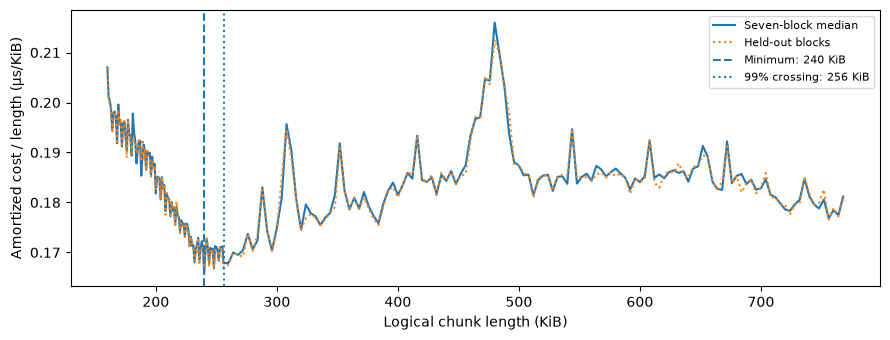

In [6]:
zoom = z >= 160
plt.figure(figsize=(9, 3.5))
plt.plot(z[zoom], 1000 * rho[zoom], label="Seven-block median")
plt.plot(z[zoom], 1000 * T_test[zoom] / z[zoom], ":", label="Held-out blocks")
plt.axvline(z_rho, ls="--", label=f"Minimum: {z_rho:g} KiB")
plt.axvline(s99, ls=":", label=f"99% crossing: {s99:g} KiB")
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Amortized cost / length (µs/KiB)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
below = np.sum(B_smooth[z >= s99] < .99 * B_smooth.max())
display(Markdown(
    f"**Figure 1.** Cost per KiB is minimized at **{z_rho:g} KiB** "
    f"({1000 * rho.min():.4f} µs/KiB). The first training-throughput crossing is "
    f"**{s99:g} KiB**; **{below}** later grid points fall below the threshold. "
    "The two lengths describe different summaries of the same data, not independent confirmations."))

**Figure 1.** Cost per KiB is minimized at **240 KiB** (0.1660 µs/KiB). The first training-throughput crossing is **256 KiB**; **125** later grid points fall below the threshold. The two lengths describe different summaries of the same data, not independent confirmations.

## A two-line approximation imposes constant cost per byte in its tail.

Consider the continuous family

$$\boxed{T_s(z)=c_1z+\delta\max(s,z)
=\begin{cases}\delta s+c_1z,&z\le s,\\(c_1+\delta)z,&z\ge s,\end{cases}
\qquad c_1,\delta\ge0.}$$

Continuity ties the short-chunk intercept to $s$. The long-chunk line passes through the origin, so $T_s(z)/z=c_1+\delta$ after $s$. This is a model restriction, not an observed identity.

For a fixed $s$, nonnegative least squares fits the two coefficients. The free boundary minimizes training error over $\mathcal G^\circ$, the measured grid without its first and last three sizes:

$$s_\star\in\arg\min_{s\in\mathcal G^\circ}\min_{c_1,\delta\ge0}
\frac1{|\mathcal G|}\sum_{z\in\mathcal G}[T_{\mathrm{train}}(z)-T_s(z)]^2.$$

The continuous hinge $T_H(z)=a+bz+d(z-h)_+$ instead permits a nonzero tail intercept $a-dh$. Its unconstrained coefficients and boundary $h$ minimize the same training loss. Thus the free two-line family has three parameters, while the free hinge has four.

In [8]:
def rmse(observed, predicted):
    return np.sqrt(np.mean((observed - predicted) ** 2))


def X_s(s):
    return np.column_stack((z, np.maximum(s, z)))


def T_s(s):
    return X_s(s) @ nnls(X_s(s), T_train)[0]


G = z[3:-3]
E_s = np.array([rmse(T_train, T_s(s)) for s in G])
s_star = G[np.argmin(E_s)]

In [9]:
def X_h(h):
    return np.column_stack((np.ones_like(z), z, np.maximum(z - h, 0)))


def T_h(h):
    return X_h(h) @ np.linalg.lstsq(X_h(h), T_train, rcond=None)[0]


E_h = np.array([rmse(T_train, T_h(h)) for h in G])
h_star = G[np.argmin(E_h)]
band = G[E_s <= 1.01 * E_s.min()]

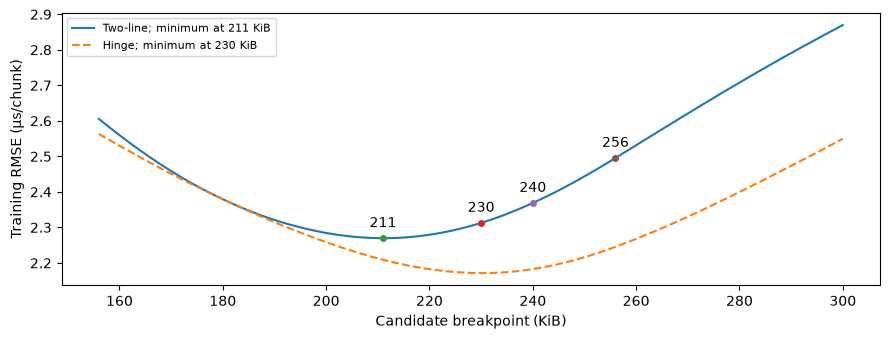

In [10]:
local = (G >= min(s_star, h_star, 230) - 55) & (G <= max(s_star, h_star, 256) + 45)
plt.figure(figsize=(9, 3.5))
plt.plot(G[local], 1000 * E_s[local], label=f"Two-line; minimum at {s_star:g} KiB")
plt.plot(G[local], 1000 * E_h[local], "--", label=f"Hinge; minimum at {h_star:g} KiB")
for s in sorted(set((s_star, 230, 240, 256))):
    error = 1000 * rmse(T_train, T_s(s))
    plt.plot(s, error, "o", ms=4)
    plt.annotate(f"{s:g}", (s, error), xytext=(0, 8), textcoords="offset points", ha="center")
plt.xlabel("Candidate breakpoint (KiB)")
plt.ylabel("Training RMSE (µs/chunk)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
a, b, d = np.linalg.lstsq(X_h(h_star), T_train, rcond=None)[0]
display(Markdown(
    f"**Figure 2.** The two-line and hinge boundaries are **{s_star:g}** and "
    f"**{h_star:g} KiB**, respectively. The hinge tail intercept is "
    f"**{1000 * (a - d * h_star):.3f} µs**; the two-line tail intercept is zero. "
    f"Two-line boundaries from **{band.min():g}–{band.max():g} KiB** lie within 1% "
    "of minimum training RMSE. This is a sensitivity set, not a confidence interval."))

**Figure 2.** The two-line and hinge boundaries are **211** and **230 KiB**, respectively. The hinge tail intercept is **-2.645 µs**; the two-line tail intercept is zero. Two-line boundaries from **198–224 KiB** lie within 1% of minimum training RMSE. This is a sensitivity set, not a confidence interval.

## Held-out blocks compare approximations, not SSD speeds.

Fit each nominated boundary $s\in\{230,240,256\}$ separately and include the affine baseline $T_A(z)=a+bz$. Every model has fitted coefficients; fixed and free refer only to its boundary. Freeze all fits before evaluating

$$\mathrm{RMSE}=\sqrt{\frac1{|\mathcal G|}\sum_z[\widehat T(z)-T_{\mathrm{test}}(z)]^2},\qquad
\mathrm{MAPE}=\frac{100}{|\mathcal G|}\sum_z\frac{|\widehat T(z)-T_{\mathrm{test}}(z)|}{T_{\mathrm{test}}(z)}.$$

Measured sizes receive equal weight. The nominated boundaries were chosen after inspecting this run; in particular, 240 KiB came from all seven blocks. Their comparison is retrospective, not a fresh confirmatory holdout experiment.

In [12]:
predictions = {f"Two-line ({s} KiB)": T_s(s) for s in (240, 256, 230)}
free_line = f"Two-line ({s_star:g} KiB, free)"
free_hinge = f"Hinge ({h_star:g} KiB, free)"
predictions[free_line] = T_s(s_star)
predictions[free_hinge] = T_h(h_star)
X_a = np.column_stack((np.ones_like(z), z))
predictions["Affine"] = X_a @ np.linalg.lstsq(X_a, T_train, rcond=None)[0]

In [13]:
comparison = pd.DataFrame({name: {
    "Train RMSE (µs)": 1000 * rmse(T_train, prediction),
    "Holdout RMSE (µs)": 1000 * rmse(T_test, prediction),
    "Holdout MAPE (%)": 100 * np.mean(np.abs(prediction - T_test) / T_test),
} for name, prediction in predictions.items()}).T
comparison.index.name = "Model"
comparison.round(3)

,Train RMSE (µs),Holdout RMSE (µs),Holdout MAPE (%)
Model,,,
Two-line (240 KiB),2.369,2.323,3.803
Two-line (256 KiB),2.496,2.456,4.267
Two-line (230 KiB),2.313,2.265,3.592
"Two-line (211 KiB, free)",2.270,2.218,3.332
"Hinge (230 KiB, free)",2.171,2.094,2.919
Affine,3.819,3.816,10.004


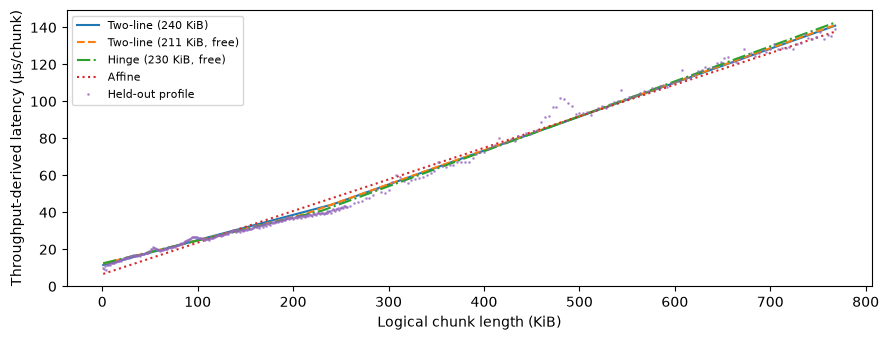

In [14]:
main_models = ["Two-line (240 KiB)", free_line, free_hinge]
plt.figure(figsize=(9, 3.5))
for name, style in zip(main_models + ["Affine"], ["-", "--", "-.", ":"]):
    plt.plot(z, 1000 * predictions[name], style, label=name)
plt.plot(z, 1000 * T_test, ".", ms=2, alpha=.6, label="Held-out profile")
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Throughput-derived latency (µs/chunk)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
display(Markdown(
    "**Figure 3.** Training-fitted curves against the held-out profile. "
    f"The free two-line model has **{comparison.loc[free_line, 'Holdout MAPE (%)']:.2f}%** MAPE, "
    f"compared with **{comparison.loc['Affine', 'Holdout MAPE (%)']:.2f}%** for the affine baseline "
    f"and **{comparison.loc[free_hinge, 'Holdout MAPE (%)']:.2f}%** for the hinge. "
    "These are errors of approximation, not changes in physical read speed."))

**Figure 3.** Training-fitted curves against the held-out profile. The free two-line model has **3.33%** MAPE, compared with **10.00%** for the affine baseline and **2.92%** for the hinge. These are errors of approximation, not changes in physical read speed.

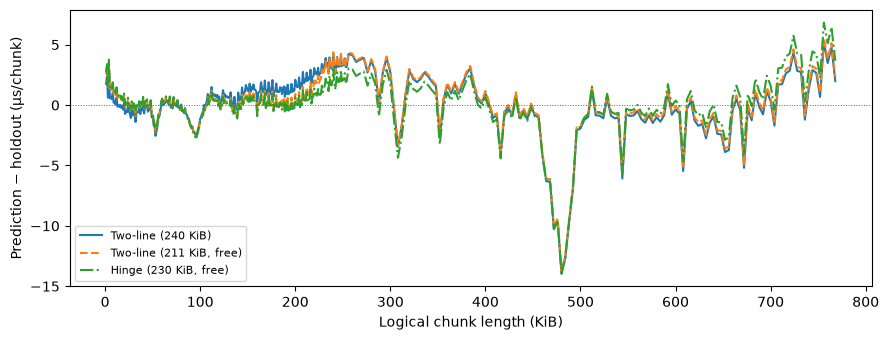

In [16]:
plt.figure(figsize=(9, 3.5))
for name, style in zip(main_models, ["-", "--", "-."]):
    plt.plot(z, 1000 * (predictions[name] - T_test), style, label=name)
plt.axhline(0, ls=":", lw=.7)
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Prediction − holdout (µs/chunk)")
plt.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

**Figure 4.** Negative residuals indicate underestimated latency. Departures shared by the fitted curves are not removed simply by moving the boundary.

## The approximation remains conditional on its model and measured range.

The lengths $z_\rho$, $s_{99}$, $s_\star$ and $h_\star$ answer different questions. Their disagreement is not a contradiction: changing the summary, loss or model changes the quantity being optimized.

For a weight row of $q$ KiB, $T[r]=T_{\mathrm{KiB}}(qr)$. Substitution into the selection objective gives only an approximation:

$$\boxed{L_{\mathrm{table}}(M)\approx\sum_{C\in\mathcal C(M)}T_s(q|C|).}$$

The fitted boundary is not by itself an optimal read size or a guarantee for a chunk-selection policy. Extrapolation beyond the measured range, agreement with another device and renewed native measurements are not established by this cached analysis.